# Reports Generation (Country/City-wise)
Let's explore the different kinds of reports we can generate using the current codebase:

In [1]:
import sys
from pathlib import Path

# Ensure we can import from the project root
sys.path.append(str(Path.cwd().parent))

from src.core.processing.photo_processor import load_and_preprocess_photos
from src.core.visualization.travel_visualizer import (
    TravelVisualizer,
)
from src.infrastructure.persistence.cache import ThumbnailCache
from src.app.core.config import CACHE_PATH

## 1. Load Fetched Metadata
Load the preprocessed metadata containing detailed photo information for time analysis.

In [2]:
df, travel, home = load_and_preprocess_photos()

print(f"Total photos : {len(df)}")
print(f"Travel photos: {len(travel)} across {travel['country'].nunique()} countries")

Total photos : 6850
Travel photos: 4570 across 12 countries


## 2. Load Thumbnail Cache
Load the precomputed thumbnail cache, which accelerates histogram generation by avoiding redundant image processing.

In [3]:
cache = ThumbnailCache(CACHE_PATH)

[cache] Loaded 3968 entries from C:\Users\Aya\Desktop\Immich\data\thumbnails_analysis.json


In [4]:
# See top countries to pick from
travel["country"].value_counts().head(10)

country
Japan                          801
Indonesia                      676
Sri Lanka                      622
Vietnam                        575
People's Republic of China     481
United Republic of Tanzania    423
Cambodia                       375
Malaysia                       276
United Arab Emirates           242
Saudi Arabia                    59
Name: count, dtype: int64

## 3. Initialize TravelVisualizer
Initialize the `TravelVisualizer` class, which provides helper methods for generating various visualizations.

The `min_images_thresh` parameter filters out locations with fewer images than the threshold.

In [5]:
viz = TravelVisualizer(travel, cache, min_images_thresh=5)

## 4. Define Target Countries

**Note:** Some reports (e.g., Time Analysis, Chronological Timeline) accept a list of multiple countries. However, others (e.g., Histogram Analysis, Top Places) only accept a single country. Please check the method parameters before execution!

In [6]:
# Test multiple countries together!

target_countries = ["Sri Lanka","Malaysia","Cambodia","Vietnam","Indonesia"]


## 5. Country Histogram
Generates an hourly distribution (histogram) of photos taken in a specific country.

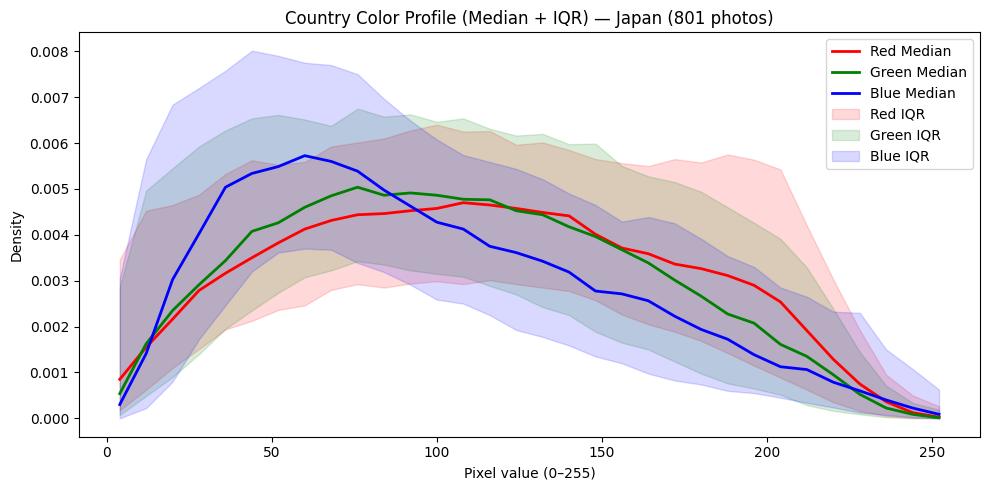

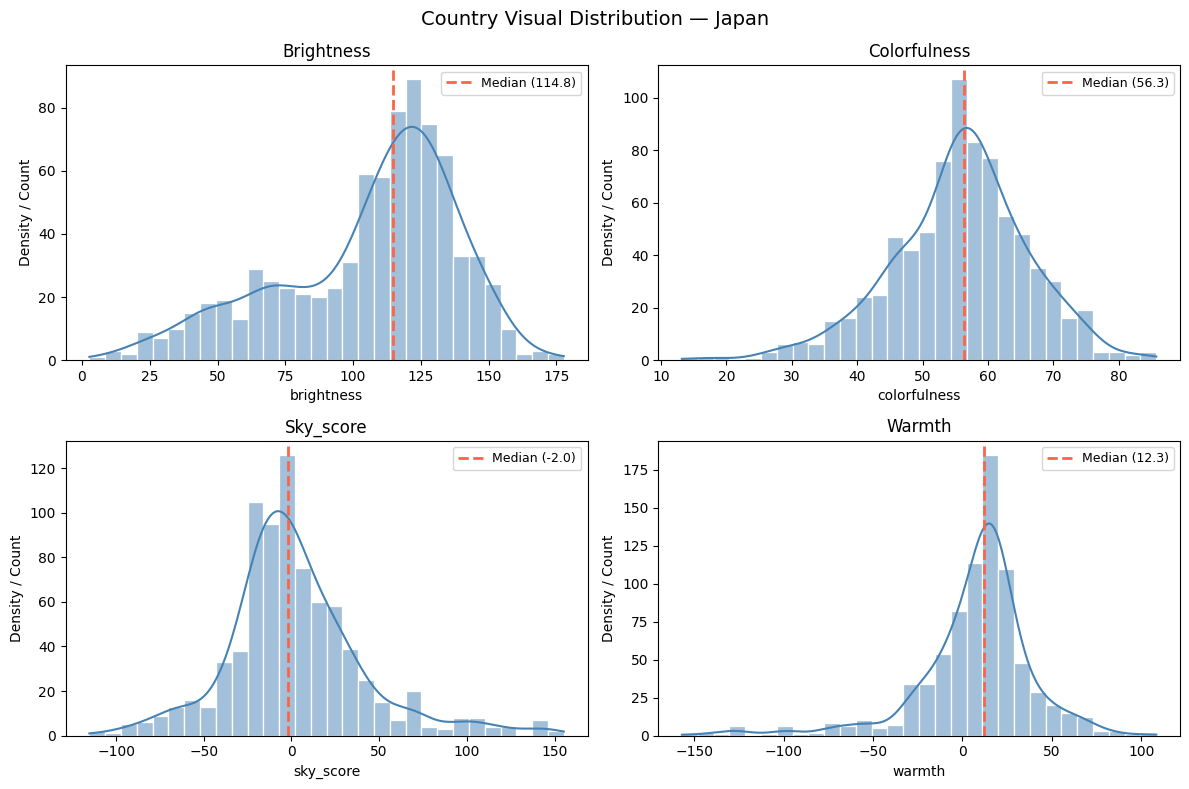

In [7]:
viz.plot_country_histogram_report(country="Japan")

# Country Timeline

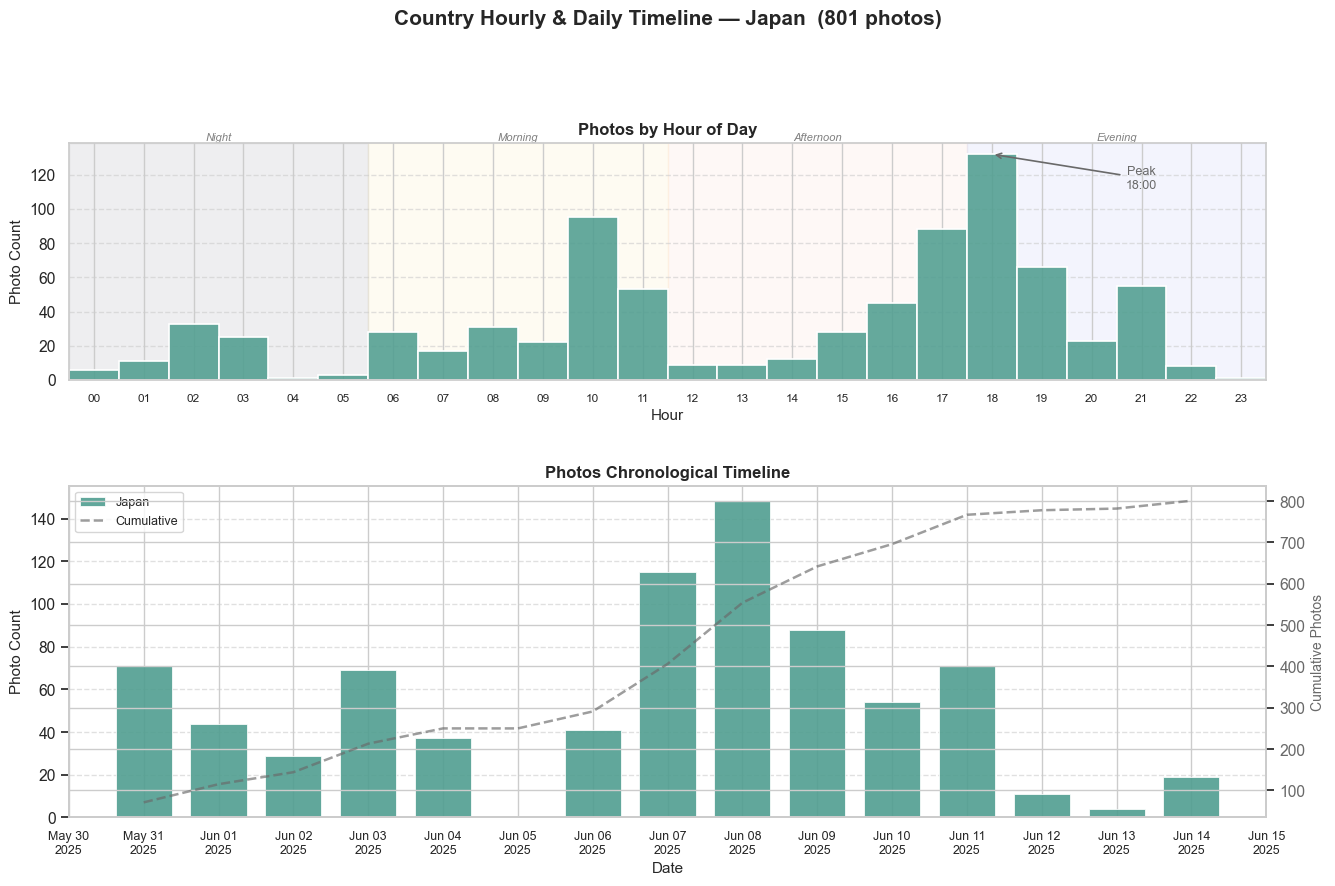

In [8]:
viz.plot_country_timestamp_report(country="Japan")

# So simple right ? , now let's try combining some countries together

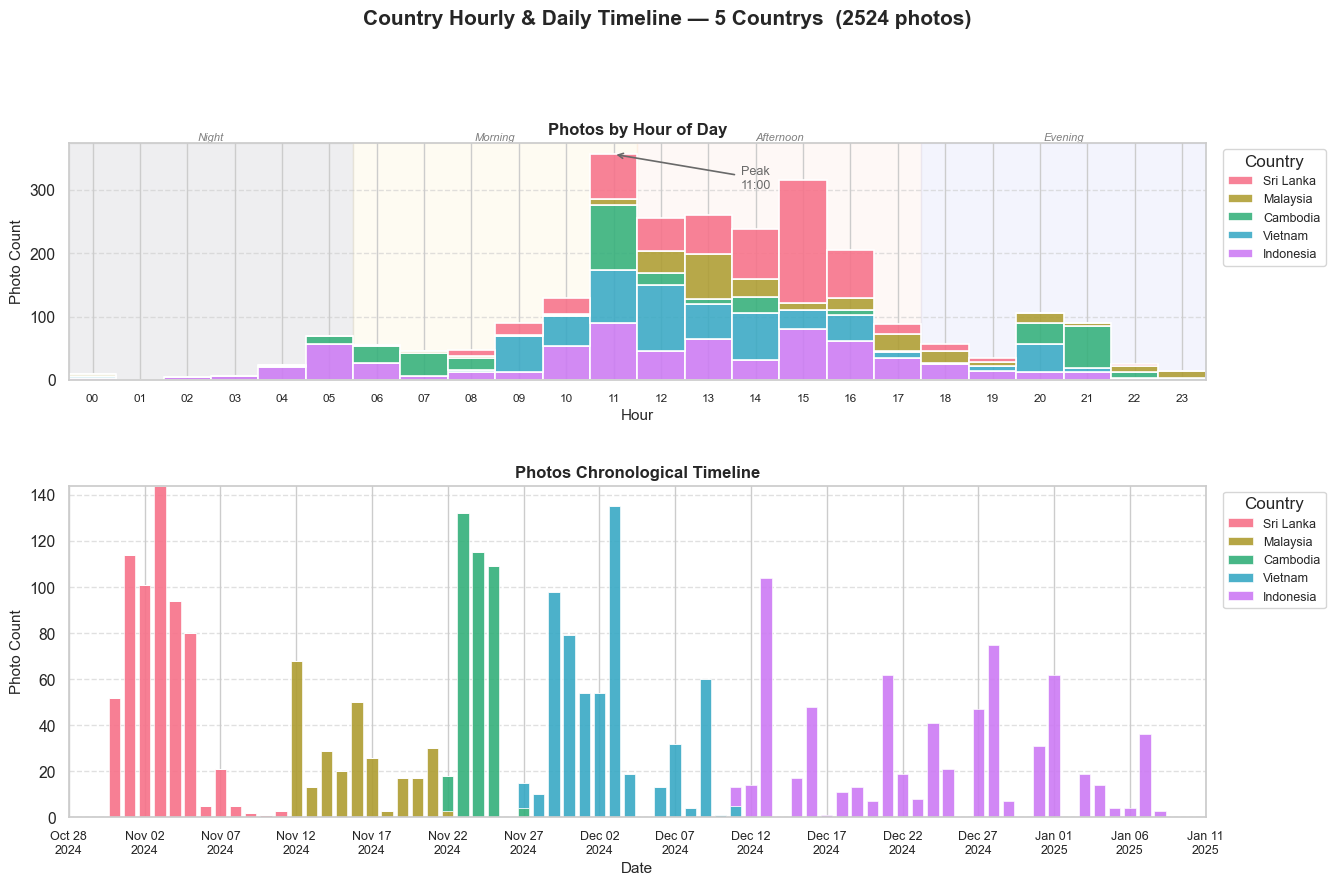

In [9]:
# the timeline supports multiple inputs
viz.plot_country_timestamp_report(country=target_countries)

# For any of the above , you could generate for specific cities just use the following methods instead :
```python
plot_city_histogram_report()
plot_city_timestamp_report()
```
# and follow the same rules :)

# ---------------------------------------------------------------

## If you wanna try my llm demo , you need to generate a report per city and then feed everything with a prompt to your favorite model.
## it can be tedious if you have several locations in a single country so i created the following methods to help you out 
## generate_full_country_report() will do all the work for you and return the images for each report for each city in the specified country + a report for the country itself, so you can just select all and upload

## it also comes with a md flavor for you to check :)

In [12]:
viz.generate_full_country_report(
    country="Japan",             # Change to whichever country you want
    base_save_dir="reports"      # It will create './reports/Japan/'
)

Generating full report for Japan in 'reports\Japan'...
  -> Generating reports for city: Minato City
  -> Generating reports for city: Azabu-jūban
  -> Generating reports for city: Higashi-nihombashi
  -> Generating reports for city: Kanda-awajichō
  -> Generating reports for city: Heiwadai
  -> Generating reports for city: Tokyo
  -> Generating reports for city: Sakuragaokachō
  -> Generating reports for city: Mukō
  -> Generating reports for city: Kyoto
  -> Generating reports for city: Kamigyō-ku
  -> Generating reports for city: Arashiyama
  -> Generating reports for city: Nara-shi
  -> Generating reports for city: Osaka
  -> Generating reports for city: Sakai
  -> Generating reports for city: Matsubara
  -> Generating reports for city: Amagasaki
Done! All reports saved in reports\Japan/


In [13]:
viz.generate_country_markdown_report(country="Japan",base_save_dir="reports")

Generating full report for Japan in 'reports\Japan'...
  -> Generating reports for city: Minato City
  -> Generating reports for city: Azabu-jūban
  -> Generating reports for city: Higashi-nihombashi
  -> Generating reports for city: Kanda-awajichō
  -> Generating reports for city: Heiwadai
  -> Generating reports for city: Tokyo
  -> Generating reports for city: Sakuragaokachō
  -> Generating reports for city: Mukō
  -> Generating reports for city: Kyoto
  -> Generating reports for city: Kamigyō-ku
  -> Generating reports for city: Arashiyama
  -> Generating reports for city: Nara-shi
  -> Generating reports for city: Osaka
  -> Generating reports for city: Sakai
  -> Generating reports for city: Matsubara
  -> Generating reports for city: Amagasaki
Done! All reports saved in reports\Japan/
✅ Markdown report saved → reports\Japan\report.md


'# 🗺️ Travel Report — Japan\n\n> **Generated:** 2026-03-09 01:47\n\n## Overview\n\n| | |\n|:---|:---|\n| 📷 **Total Photos** | 801 |\n| 📅 **Date Range** | May 31, 2025 → Jun 14, 2025 |\n| ⏱️ **Trip Duration** | 15 days |\n| 🏙️ **Cities Visited** | 16 — Minato City, Azabu-jūban, Higashi-nihombashi, Kanda-awajichō, Heiwadai, Tokyo, Sakuragaokachō, Mukō, Kyoto, Kamigyō-ku, Arashiyama, Nara-shi, Osaka, Sakai, Matsubara, Amagasaki |\n| 🕐 **Peak Shooting Hour** | 18:00 |\n| 📆 **Busiest Day** | Jun 08, 2025 (148 photos) |\n\n## City Breakdown\n\n| City | Photos | First Photo | Last Photo | Duration | Peak Hour |\n|:-----|-------:|:-----------:|:----------:|---------:|:---------:|\n| Minato City | 23 | May 31, 2025 | May 31, 2025 | 1d | 18:00 |\n| Azabu-jūban | 48 | May 31, 2025 | Jun 01, 2025 | 2d | 18:00 |\n| Higashi-nihombashi | 51 | Jun 01, 2025 | Jun 06, 2025 | 6d | 11:00 |\n| Kanda-awajichō | 25 | Jun 02, 2025 | Jun 04, 2025 | 3d | 08:00 |\n| Heiwadai | 63 | Jun 03, 2025 | Jun 03, 2025 | 